In [ ]:
install.packages('mosaic')
install.packages('ggplot2')

library(ggplot2)
library('mosaic')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘fontBitstreamVera’, ‘fontLiberation’, ‘fontquiver’, ‘gdtools’, ‘ggiraph’, ‘ggridges’, ‘labelled’, ‘ggformula’, ‘mosaicData’, ‘mosaicCore’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2


The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.


Attaching package: ‘mosaic’


The following objects are masked from ‘package:dplyr’:

    count, do, tally


The following object is masked from ‘package:Matrix’:

    mean


The following object is masked from ‘package:ggplot2’:

    stat


The following objects are masked from ‘package:stats’:

    binom.test, cor, cor.test, cov, fivenum, IQR, 

# **QUESTÃO 3**

In [4]:
media <- 62
desvio_padrao <- 3.5
variancia <- desvio_padrao * desvio_padrao #R usa o desvio padrão diretamente, teremos a variancia por precaução :)



Distibuição da Temperatura da CPU:



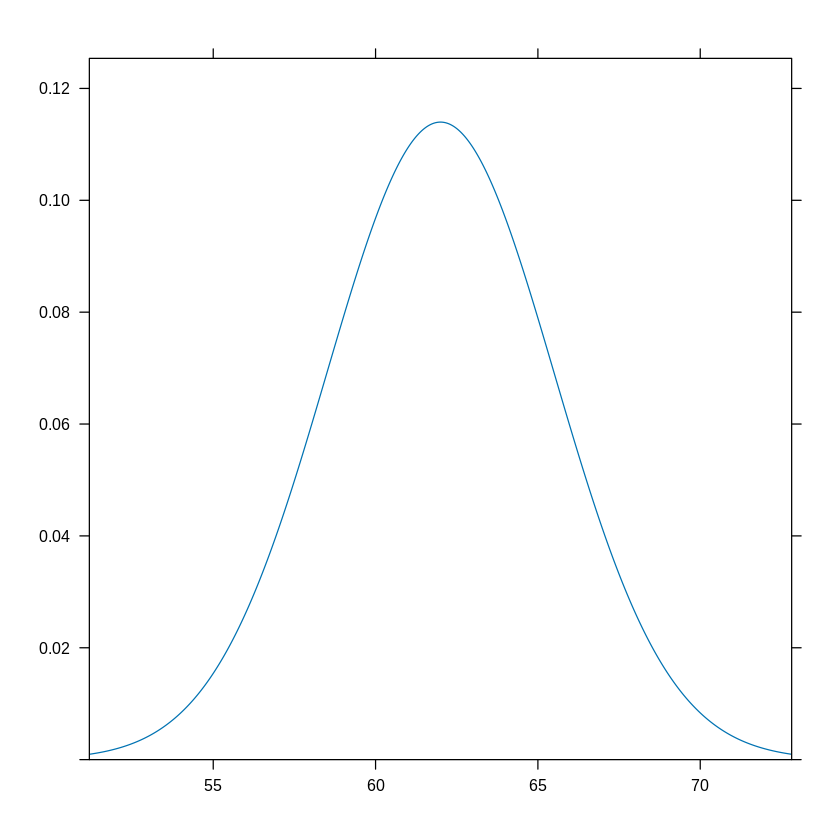

In [ ]:
cat("Distibuição da Temperatura da CPU:\n\n")
plotDist('norm', mean = media, sd = desvio_padrao)

## **Item 1**

In [ ]:
set.seed(2)


#Item A
u1 <- runif(1, 0, 1)
u2 <- runif(1, 0, 1)

u1
u2

#Item B
z1 <- sqrt(-2*log(u1, base=exp(1)))*cos(2*pi*u2)
z2 <- sqrt(-2*log(u1, base=exp(1)))*sin(2*pi*u2)

z <- c(z1, z2)

#Item C

CPU_T <- media + desvio_padrao*z


[1] 0.1848823

[1] 0.702374

In [6]:
generator <- function(n){
  set.seed(2)

  u1 <- runif(n/2, 0, 1) #COMO CONCATENAREMOS OS VETORES, ENTÃO É NATURAL QUE SE QUISERMOS 1000
  u2 <- runif(n/2, 0, 1) #CRIAREMOS 500 EM CADA DISTRIBUIÇÃO

  z1 <- sqrt(-2*log(u1, base=exp(1)))*cos(2*pi*u2)
  z2 <- sqrt(-2*log(u1, base=exp(1)))*sin(2*pi*u2)

  z <- c(z1, z2)

  return (z)
}

## **Item 2**

In [7]:
CPU_T <- media + desvio_padrao*generator(1000)
CPU_T_R <- rnorm(1000, media, desvio_padrao)


## **Item 3**

In [ ]:
#Item a -- MEDIA

  #Generator
  MEDIA_CPU_T <- sum(CPU_T)/length(CPU_T)
  MEDIA_R_CPU_T <- mean(CPU_T)

  #rnorm
  MEDIA_CPU_T_R <- sum(CPU_T_R)/length(CPU_T_R)
  MEDIA_R_CPU_T_R <- mean(CPU_T_R)

cat("\nMEDIA:\n")
cat("GERADOR          Calculados       X       R     \n")
cat("generator        ", MEDIA_CPU_T,"           ", MEDIA_R_CPU_T, "\n")
cat("rnorm            ", MEDIA_CPU_T_R,"           ", MEDIA_R_CPU_T_R, "\n")

#Item B -- DESVIO PADRÃO
#Usaremos o n-1 como fator do desvio padrão em vez do n, pois essas medições não refletem todos os valores de temperatura da CPU, ou seja, a média estará enviezada

  #Generator
  DP_CPU_T <- sqrt(sum((CPU_T - MEDIA_CPU_T)**2)/(length(CPU_T) - 1))
  DP_R_CPU_T <- sd(CPU_T)

  #rnorm
  DP_CPU_T_R <- sqrt(sum((CPU_T_R - MEDIA_CPU_T_R)**2)/(length(CPU_T_R) - 1))
  DP_R_CPU_T_R <- sd(CPU_T_R)

cat("\nDESVIO PADRÃO:\n")
cat("GERADOR          Calculados       X       R     \n")
cat("generator        ", DP_CPU_T,"           ", DP_R_CPU_T, "\n")
cat("rnorm            ", DP_CPU_T_R,"           ", DP_R_CPU_T_R, "\n")





MEDIA:
GERADOR          Calculados       X       R     
generator         61.98125             61.98125 
rnorm             62.16023             62.16023 

DESVIO PADRÃO:
GERADOR          Calculados       X       R     
generator         3.572245             3.572245 
rnorm             3.438481             3.438481 


In [ ]:
#Item C -- MÍNIMO E MÁXIMO

  #Generator
  MIN_R_CPU_T <- min(CPU_T)
  MAX_R_CPU_T <- max(CPU_T)

  SORTED_CPU_T <- sort(CPU_T)
  MIN_CPU_T <- SORTED_CPU_T[1]
  MAX_CPU_T <- SORTED_CPU_T[length(CPU_T)]


  #rnorm
  MIN_R_CPU_T_R <- min(CPU_T_R)
  MAX_R_CPU_T_R <- max(CPU_T_R)

  SORTED_CPU_T_R <- sort(CPU_T_R)
  MIN_CPU_T_R <- SORTED_CPU_T_R[1]
  MAX_CPU_T_R <- SORTED_CPU_T_R[length(CPU_T_R)]



cat("\nMENOR ELEMENTO:\n")
cat("GERADOR          Calculados       X       R     \n")
cat("generator        ", MIN_CPU_T,"           ", MIN_R_CPU_T, "\n")
cat("rnorm            ", MIN_CPU_T_R,"           ", MIN_R_CPU_T_R, "\n")

cat("\nMAIOR ELEMENTO:\n")
cat("GERADOR          Calculados       X       R     \n")
cat("generator        ", MAX_CPU_T,"           ", MAX_R_CPU_T, "\n")
cat("rnorm            ", MAX_CPU_T_R,"           ", MAX_R_CPU_T_R, "\n")


MENOR ELEMENTO:
GERADOR          Calculados       X       R     
generator         48.90057             48.90057 
rnorm             47.73671             47.73671 

MAIOR ELEMENTO:
GERADOR          Calculados       X       R     
generator         72.3757             72.3757 
rnorm             73.07918             73.07918 


In [ ]:
#Item D - P(T > 68) / E - EMPIRICO / T - TEORICO

  #EXPERIMENTAL
  P1_E_CPU_T   <- length(CPU_T[CPU_T > 68])/length(CPU_T)
  P1_E_CPU_T_R <- length(CPU_T_R[CPU_T_R > 68])/length(CPU_T_R)

  #TEORICO
  #P(T > 68) = 1 - P(T < 68)
  P1_T_CPU_T <- 1 - pnorm(68, media, desvio_padrao)


cat("\nPROBABILIDADE EXPERIMENTAL T > 68:\n")
cat("GERADOR          Calculados \n")
cat("generator        ", P1_E_CPU_T, "\n")
cat("rnorm            ", P1_E_CPU_T_R, "\n")

cat("\nPROBABILIDADE TEORICA T > 68: ", P1_T_CPU_T, "\n")


PROBABILIDADE EXPERIMENTAL T > 68:
GERADOR          Calculados 
generator         0.043 
rnorm             0.047 

PROBABILIDADE TEORICA T > 68:  0.04323813 


In [ ]:
#Item E - P(60 < T < 65) / E - EMPIRICO / T - TEORICO

  #EXPERIMENTAL
  P2_E_CPU_T   <- length(CPU_T[CPU_T > 60 & CPU_T < 65])/length(CPU_T)
  P2_E_CPU_T_R <- length(CPU_T_R[CPU_T_R > 60 & CPU_T_R < 65])/length(CPU_T_R)

  #TEORICO
  #P(60 < T < 65) = P(T < 65) - P(T < 60)
  P2_T_CPU_T <- pnorm(65, media, desvio_padrao) - pnorm(60, media, desvio_padrao)


cat("\nPROBABILIDADE EXPERIMENTAL T > 68:\n")
cat("GERADOR          Calculados \n")
cat("generator        ", P2_E_CPU_T, "\n")
cat("rnorm            ", P2_E_CPU_T_R, "\n")

cat("\nPROBABILIDADE TEORICA T > 68: ", P2_T_CPU_T, "\n")


PROBABILIDADE EXPERIMENTAL T > 68:
GERADOR          Calculados 
generator         0.521 
rnorm             0.523 

PROBABILIDADE TEORICA T > 68:  0.5204624 


In [ ]:
#Item D - P(T > 75) / E - EMPIRICO / T - TEORICO

  #EXPERIMENTAL
  P3_E_CPU_T   <- length(CPU_T[CPU_T > 75])/length(CPU_T)
  P3_E_CPU_T_R <- length(CPU_T_R[CPU_T_R > 75])/length(CPU_T_R)

  #TEORICO
  #P(T > 75) = 1 - P(T < 75)
  P3_T_CPU_T <- 1 - pnorm(75, media, desvio_padrao)


cat("\nPROBABILIDADE EXPERIMENTAL T > 68:\n")
cat("GERADOR          Calculados \n")
cat("generator        ", P3_E_CPU_T, "\n")
cat("rnorm            ", P3_E_CPU_T_R, "\n")

cat("\nPROBABILIDADE TEORICA T > 68: ", P3_T_CPU_T, "\n")


PROBABILIDADE EXPERIMENTAL T > 68:
GERADOR          Calculados 
generator         0 
rnorm             0 

PROBABILIDADE TEORICA T > 68:  0.0001018892 


## **Item 4**

In [9]:
calc_norm <- function(x){
  num = exp((-0.5)*((x-media)/desvio_padrao)**2)
  den = desvio_padrao * sqrt(2*pi)

  return (num/den)

}

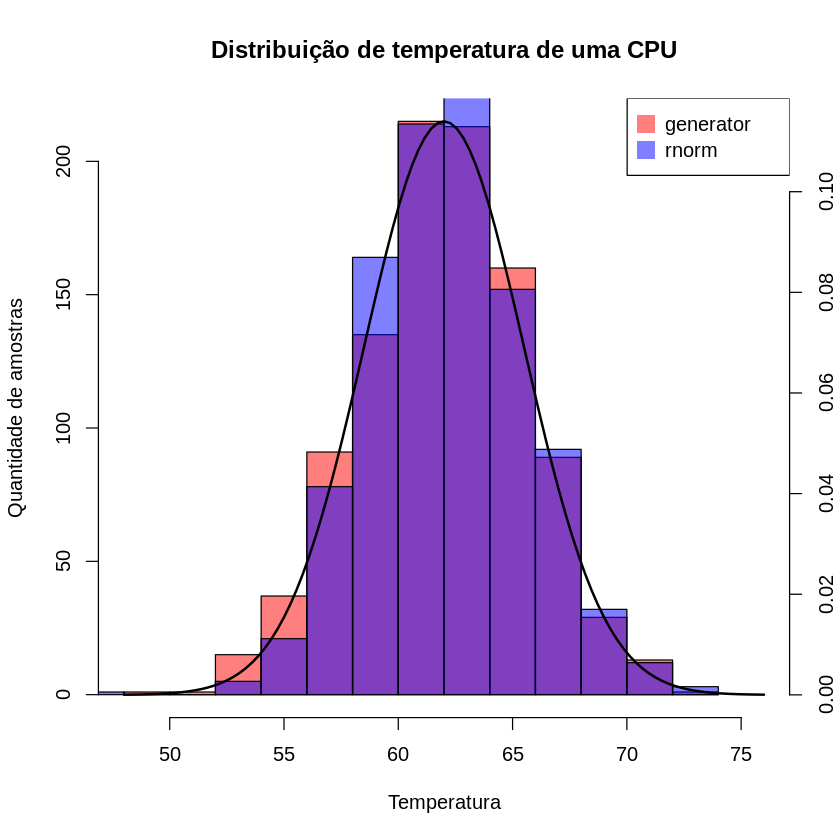

In [10]:
hist(CPU_T, breaks = 15, xlim=c(media - 4*desvio_padrao , media + 4*desvio_padrao), col=rgb(1,0,0,0.5), xlab="Temperatura",
     ylab="Quantidade de amostras", main="Distribuição de temperatura de uma CPU" )

hist(CPU_T_R, breaks = 15, xlim=c(media - 4*desvio_padrao , media + 4*desvio_padrao), col=rgb(0,0,1,0.5), add=T)

par(new = T)
curve(calc_norm(x), from= media - 4*desvio_padrao, to= media + 4*desvio_padrao,
      col="black", lwd=2, xlab = "", ylab = "", axes = FALSE,
      xlim=c(media - 4*desvio_padrao , media + 4*desvio_padrao))

axis(side = 4)


legend("topright", legend=c("generator","rnorm"), col=c(rgb(1,0,0,0.5),
     rgb(0,0,1,0.5)), pt.cex=2, pch=15 )